In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Loading Student Performence Dataset
df = pd.read_csv("C:/Users/Admin/Machine Learning Algorithms/Datasets/Student_Performance.csv")

In [4]:
df.head()

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [5]:
# Data Preprocessing 
# Drop unnecessary columns
df = df.drop(columns=["student_id", "final_grade"])

# Define target variable
y = df["overall_score"]

# Define features
X = df.drop(columns=["overall_score"])

# Convert categorical columns using One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Convert to numpy arrays
X = X.astype(float).values
y = y.astype(float).values

In [6]:
# Train Test Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (20000, 24)
Testing Shape: (5000, 24)


In [7]:
# Add column of ones for intercept
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [8]:
# Normal Equation
theta = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

print("Model Parameters (Theta):")
print(theta)

Model Parameters (Theta):
[-2.15062482e-01 -1.35111078e-02  4.03585982e+00  2.05110433e-01
  1.67603529e-01  1.70498515e-01  1.62374471e-01 -4.82566105e-02
 -1.64684141e-01 -3.67791762e-02  1.09178539e-01  1.19783027e-01
  1.56091786e-01 -4.13543167e-02  2.88196080e-01 -1.09682096e-01
 -2.53924237e-02  1.07692664e-01  2.90826828e-02 -3.68020307e-04
  6.54522936e-02 -1.00442581e-01 -3.65330870e-02  2.09962300e-01
 -4.31529240e-02]


In [9]:
y_pred = X_test @ theta

In [10]:
y_pred = X_test @ theta

In [11]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 17.07231619727114
R2 Score: 0.9529780541236547


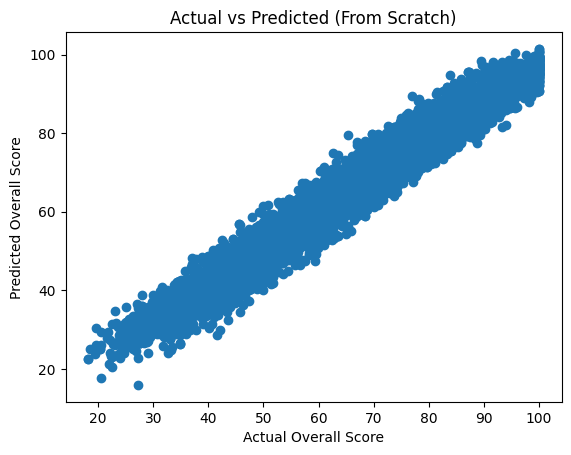

In [12]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Actual vs Predicted (From Scratch)")
plt.show()